# $(SASA) Triplet$

<!-- $loss = mse(\hat{\theta'},\hat{\theta}) + mse(\hat{s''},s'') + mse(\hat{s'''},y)$  -->
$loss = max\{||\hat{\theta_i^a} - \hat{\theta_j^a}|| - ||\hat{\theta_i^a} - \hat{\theta_k^b}|| + \alpha, 0\}$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model, Triplet_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
560,17,26,"(0.23, 1.9)","(-0.21, -0.583, 0.049, 0.258)",1,1.0,"(-0.222, -0.397, 0.054, 0.178)",1.0,1.0,"(-0.23, -0.212, 0.058, 0.098)"
413,8,20,"(0.46, 0.6)","(-0.07, -0.396, 0.037, 0.623)",0,1.0,"(-0.078, -0.593, 0.049, 0.966)",0.0,1.0,"(-0.089, -0.791, 0.068, 1.314)"
2112,1,91,"(0.77, 1.4)","(-0.021, 0.232, 0.032, -0.218)",0,1.0,"(-0.016, 0.04, 0.027, -0.007)",1.0,1.0,"(-0.015, 0.231, 0.027, -0.206)"
257,0,12,"(0.5, 0.9)","(-0.025, 0.045, -0.031, -0.032)",1,1.0,"(-0.024, 0.237, -0.032, -0.269)",1.0,1.0,"(-0.019, 0.43, -0.037, -0.507)"
1130,38,49,"(0.23, 1.3)","(-0.092, 0.011, 0.031, -0.02)",1,1.0,"(-0.092, 0.198, 0.03, -0.14)",1.0,1.0,"(-0.088, 0.385, 0.027, -0.26)"
...,...,...,...,...,...,...,...,...,...,...
507,44,23,"(0.6, 1.5)","(-0.474, -1.111, 0.183, 0.717)",1,1.0,"(-0.496, -0.923, 0.197, 0.599)",0.0,1.0,"(-0.515, -1.113, 0.209, 0.778)"
604,24,27,"(0.61, 0.5)","(-0.059, -0.016, 0.055, -0.071)",0,1.0,"(-0.06, -0.22, 0.053, 0.422)",0.0,1.0,"(-0.064, -0.425, 0.062, 0.914)"
1824,2,77,"(0.89, 0.0)","(0.033, 0.007, -0.041, -0.055)",0,1.0,"(0.033, -0.205, -0.042, 0.606)",0.0,1.0,"(0.029, -0.417, -0.029, 1.266)"
1330,15,57,"(0.14, 1.7)","(0.058, 0.181, 0.015, -0.072)",0,1.0,"(0.062, -0.005, 0.014, 0.018)",1.0,1.0,"(0.062, 0.181, 0.014, -0.069)"


In [3]:
model = Model(transition_criterion_clss=Triplet_Loss)

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, margin=.5)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,triplet,mse_s,transition,reward
0,0,1.007837,"[0.014207873493432999, 0.5807226896286011, 0.0...",2.490977,0.300462
1,1,1.007878,"[0.01373155415058136, 0.5752479434013367, 0.01...",2.479450,0.300414
2,2,1.007919,"[0.013280988670885563, 0.569790780544281, 0.01...",2.467975,0.300365
3,3,1.007964,"[0.01285691186785698, 0.5643504858016968, 0.01...",2.456555,0.300311
4,4,1.008008,"[0.01246006228029728, 0.5589227080345154, 0.01...",2.445186,0.300242


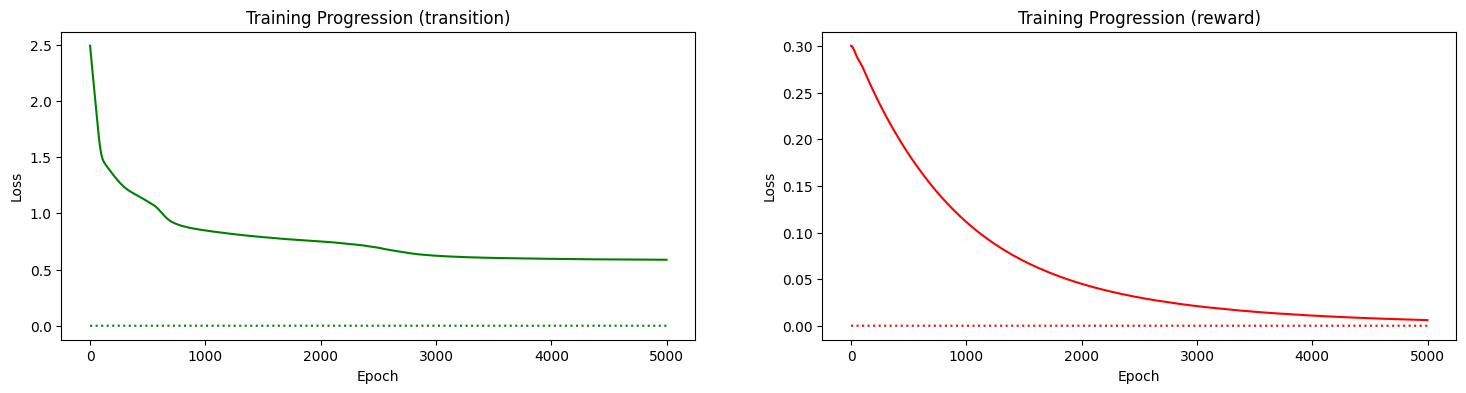

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

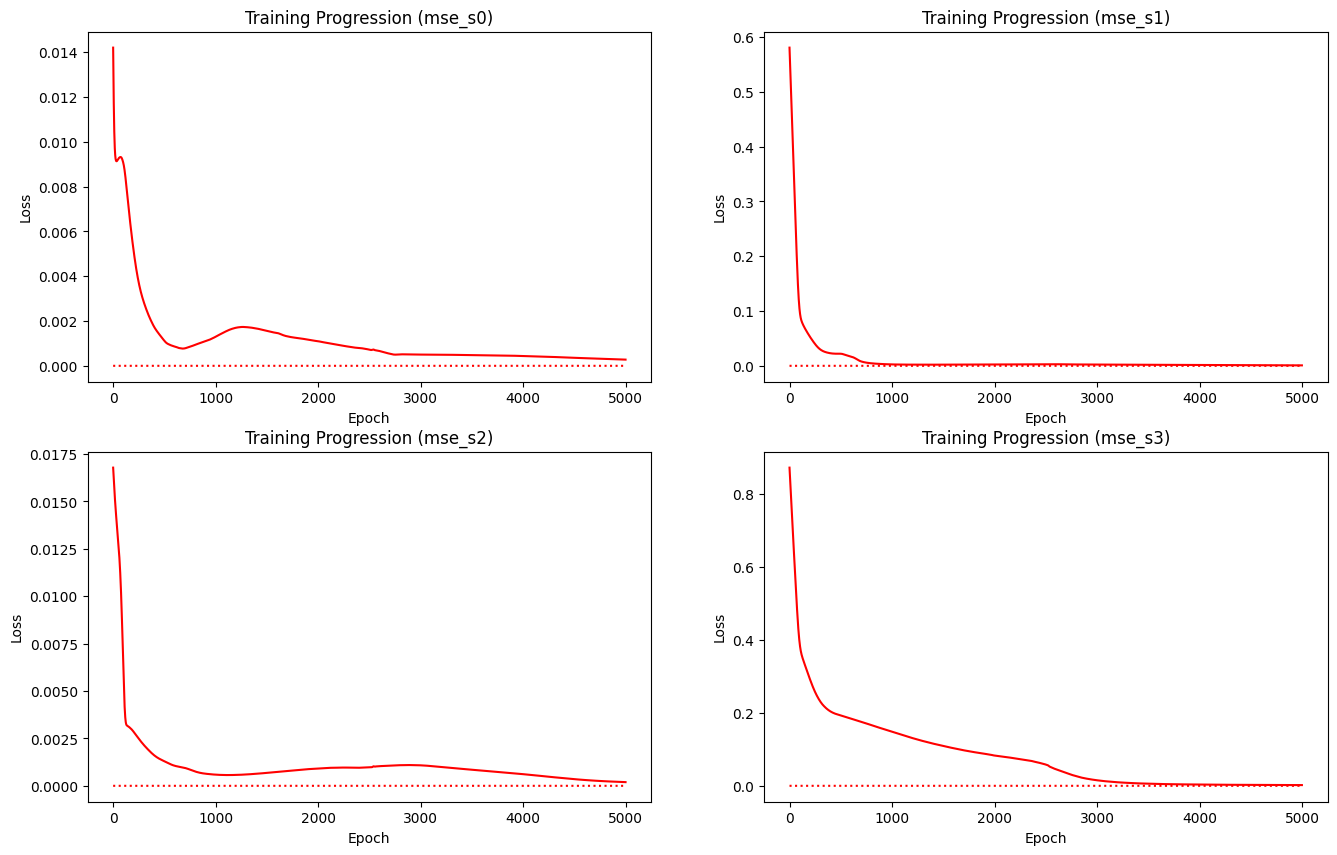

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

In [6]:
df.head()

,epoch,triplet,mse_s,transition,reward,mse_s0,mse_s1,mse_s2,mse_s3
0,0,1.007837,"[0.014207873493432999, 0.5807226896286011, 0.0...",2.490977,0.300462,0.014208,0.580723,0.016783,0.871426
1,1,1.007878,"[0.01373155415058136, 0.5752479434013367, 0.01...",2.479450,0.300414,0.013732,0.575248,0.016683,0.865910
2,2,1.007919,"[0.013280988670885563, 0.569790780544281, 0.01...",2.467975,0.300365,0.013281,0.569791,0.016583,0.860402
3,3,1.007964,"[0.01285691186785698, 0.5643504858016968, 0.01...",2.456555,0.300311,0.012857,0.564350,0.016482,0.854902
4,4,1.008008,"[0.01246006228029728, 0.5589227080345154, 0.01...",2.445186,0.300242,0.012460,0.558923,0.016383,0.849412


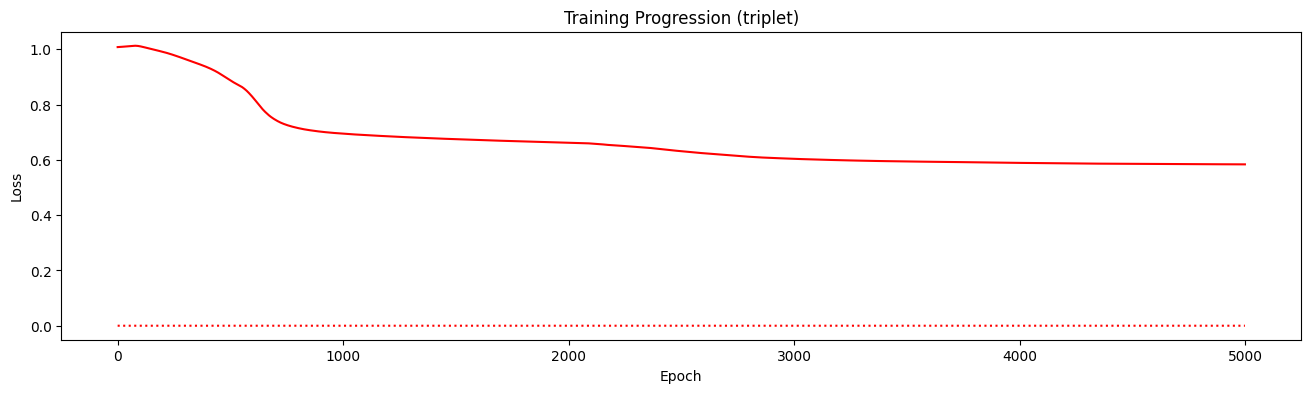

In [7]:
fig, axs = plt.subplots(1, 1, figsize=(16, 4))

data.plot_training_loss(axs, df['triplet'], 'r')

plt.show()

# Evaluation

In [ ]:
data.evaluate_model(model, path='testing_data.csv')
results = data.get_evaluation_metrics()
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.62, 1.2)","(-0.005, -0.042, -0.019, -0.009)",0,1.0,"(-0.006, -0.233, -0.02, 0.183)",1.0,1.0,"(-0.01, -0.042, -0.016, -0.018)","(-0.008, -0.039, -0.017, -0.015)","(0.42, 0.961)",0.9
1,1,0,"(0.62, 1.2)","(-0.006, -0.233, -0.02, 0.183)",1,1.0,"(-0.01, -0.042, -0.016, -0.018)",1.0,1.0,"(-0.011, 0.149, -0.016, -0.218)","(-0.006, 0.159, -0.015, -0.221)","(0.441, 1.042)",0.9
2,2,0,"(0.62, 1.2)","(-0.01, -0.042, -0.016, -0.018)",1,1.0,"(-0.011, 0.149, -0.016, -0.218)",1.0,1.0,"(-0.008, 0.34, -0.021, -0.418)","(-0.002, 0.347, -0.015, -0.418)","(0.57, 1.21)",0.9
3,3,0,"(0.62, 1.2)","(-0.011, 0.149, -0.016, -0.218)",1,1.0,"(-0.008, 0.34, -0.021, -0.418)",1.0,1.0,"(-0.001, 0.531, -0.029, -0.619)","(0.005, 0.54, -0.024, -0.62)","(0.579, 1.144)",0.9
4,4,0,"(0.62, 1.2)","(-0.008, 0.34, -0.021, -0.418)",1,1.0,"(-0.001, 0.531, -0.029, -0.619)",1.0,1.0,"(0.009, 0.722, -0.041, -0.822)","(0.014, 0.731, -0.036, -0.819)","(0.59, 1.072)",0.9


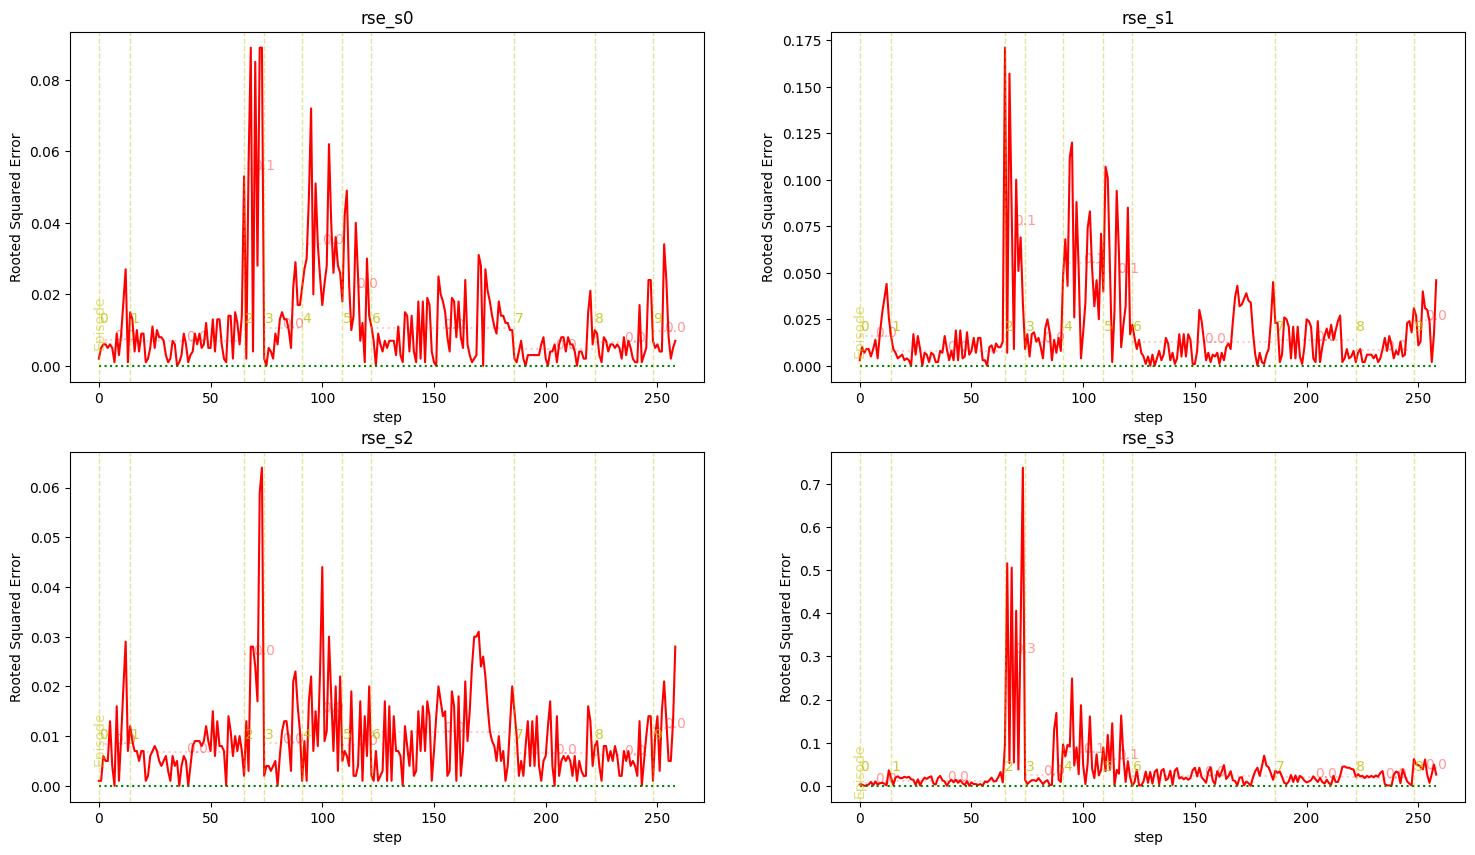

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

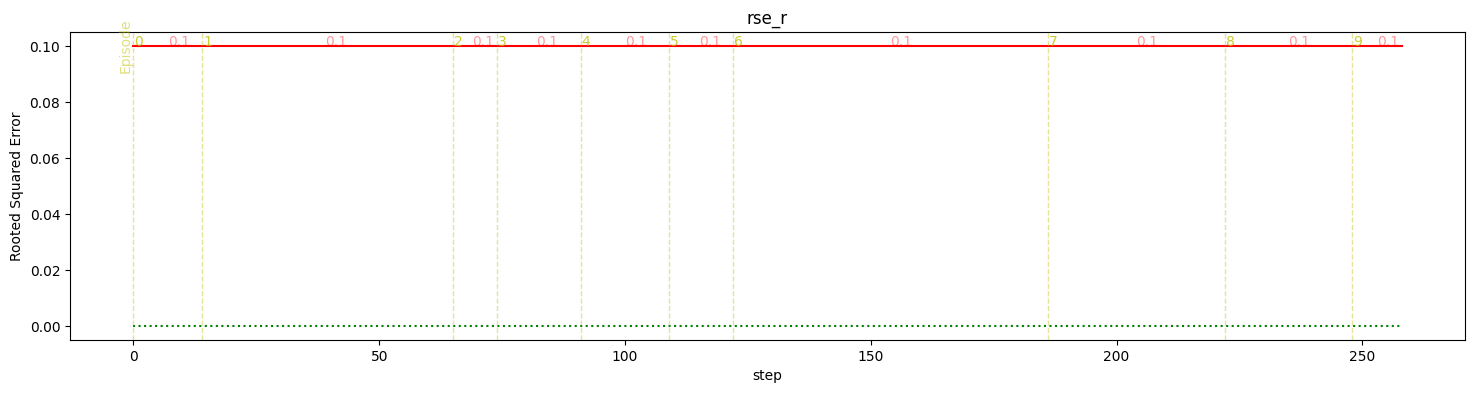

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

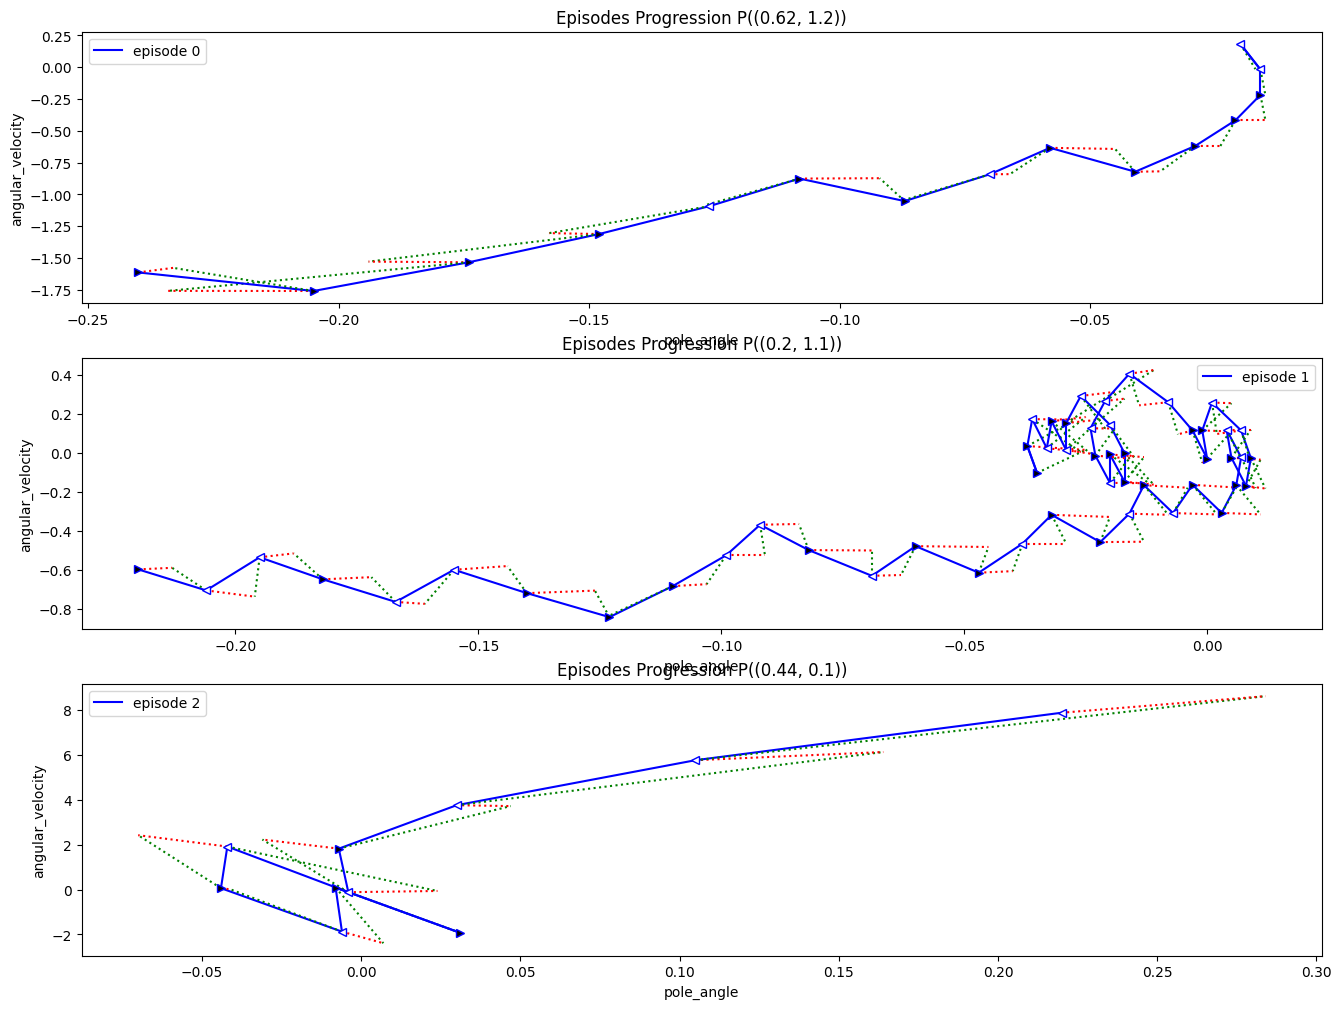

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()